# Phase 7 — Projector Head Ablation

Is the 2-layer projector actually necessary? Does the encoder output `h`
(512-d) or the projector output `z` (128-d) give a better linear probe?

SimCLR's claim: train through the projector but *throw it away* at eval —
because the projector learns to strip out information that makes the
pretext task easy but is useless downstream. So:

- **A — with projector / probe h** (default, Phase 1 result)
- **B — no projector / probe h** (512-d NT-Xent directly on encoder)
- **C — with projector / probe z** (128-d projector output as representation)

A and C share the same trained model — the only difference is which feature
vector the linear probe sees. So C is purely a re-evaluation with no extra
training cost. Only B requires a new SSL run.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    get_device, get_cifar_resnet18, get_eval_transform, get_simclr_transform,
    ProjectionHead, SimCLRModel, nt_xent_loss, knn_monitor, SimCLRPairDataset,
)

SMOKE_TEST = False

cfg = dict(
    batch_size    = 256,
    ssl_epochs    = 2  if SMOKE_TEST else 50,
    probe_epochs  = 3  if SMOKE_TEST else 50,
    lr            = 3e-4,
    probe_lr      = 1e-3,
    weight_decay  = 1e-6,
    temperature   = 0.5,
    seed          = 42,
    num_workers   = 0,
    data_root     = './data',
    knn_k         = 20,
    knn_interval  = 10,
    ckpt_dir      = 'models/ablation_projector' if not SMOKE_TEST else 'models/ablation_projector_smoke',
    results_path  = 'results/ablation_projector.json' if not SMOKE_TEST else 'results/ablation_projector_smoke.json',
    fig_path      = 'figures/ablation_projector_comparison.png' if not SMOKE_TEST else 'figures/ablation_projector_smoke.png',
    baseline_ckpt = 'models/simclr_baseline.pth',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])
os.makedirs(cfg['ckpt_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True); os.makedirs('figures', exist_ok=True)

device = get_device()
print('Device:', device)


Device: privateuseone:0


In [2]:
# --- Cell 2: Data ---
ssl_transform = get_simclr_transform(32)
eval_transform = get_eval_transform(32)

pair_ds       = SimCLRPairDataset(CIFAR10(cfg['data_root'], train=True, download=True, transform=None), transform=ssl_transform)
train_eval_ds = CIFAR10(cfg['data_root'], train=True,  download=True, transform=eval_transform)
test_ds       = CIFAR10(cfg['data_root'], train=False, download=True, transform=eval_transform)

ssl_loader    = DataLoader(pair_ds, batch_size=cfg['batch_size'], shuffle=True,
                           num_workers=cfg['num_workers'], pin_memory=False, drop_last=True)
memory_loader = DataLoader(train_eval_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)
test_loader   = DataLoader(test_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)
probe_train_loader = DataLoader(train_eval_ds, batch_size=cfg['batch_size'],
                                shuffle=True, num_workers=cfg['num_workers'],
                                pin_memory=False, drop_last=False)
print('data ready.')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
data ready.


In [3]:
# --- Cell 3: Train the 'no projector' variant (run B) ---
# Loss is computed directly on the 512-d encoder output (L2-normalized).
ckpt_path_B = os.path.join(cfg['ckpt_dir'], 'simclr_noproj.pth')

def train_no_projector():
    torch.manual_seed(cfg['seed'])
    backbone = get_cifar_resnet18().to(device)
    optimizer = torch.optim.Adam(backbone.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'loss': [], 'knn_epoch': [], 'knn_acc': [], 'epoch_sec': []}
    start_epoch = 1
    if os.path.exists(ckpt_path_B):
        ck = torch.load(ckpt_path_B, map_location='cpu', weights_only=False)
        backbone.load_state_dict(ck['backbone_state']); backbone.to(device)
        optimizer.load_state_dict(ck['optimizer_state'])
        log = ck['log']; start_epoch = ck['epoch'] + 1
        print(f'  [no-proj] RESUMING from epoch {start_epoch}', flush=True)
    else:
        print('  [no-proj] starting fresh', flush=True)

    for epoch in range(start_epoch, cfg['ssl_epochs']+1):
        backbone.train(); t0 = time.time(); loss_sum = n_batches = 0
        pbar = tqdm(ssl_loader, desc=f'noproj ep {epoch}/{cfg["ssl_epochs"]}', leave=False)
        for v1, v2, _ in pbar:
            v1 = v1.to(device); v2 = v2.to(device)
            x = torch.cat([v1, v2], dim=0)
            h = backbone(x)
            h = F.normalize(h, dim=1)
            loss = nt_xent_loss(h, temperature=cfg['temperature'])
            optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            loss_sum += float(loss.detach().cpu()); n_batches += 1
        avg_loss = loss_sum/max(n_batches,1); dt = time.time()-t0
        log['epoch'].append(epoch); log['loss'].append(avg_loss); log['epoch_sec'].append(dt)
        if epoch == 1 or epoch % cfg['knn_interval'] == 0 or epoch == cfg['ssl_epochs']:
            acc = knn_monitor(backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
            log['knn_epoch'].append(epoch); log['knn_acc'].append(acc)
            print(f'    [no-proj] ep {epoch:3d}  loss={avg_loss:.4f}  knn={acc*100:.2f}%  ({dt:.1f}s)', flush=True)
        tmp = ckpt_path_B + '.tmp'
        torch.save({'epoch': epoch, 'backbone_state': backbone.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'log': log}, tmp)
        os.replace(tmp, ckpt_path_B)
    return backbone, log

t0 = time.time()
bb_B, log_B = train_no_projector()
print(f'no-proj SSL done in {(time.time()-t0)/60:.1f} min')


  [no-proj] starting fresh


noproj ep 1/50:   0%|          | 0/195 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


    [no-proj] ep   1  loss=5.5490  knn=38.13%  (115.4s)


noproj ep 2/50:   0%|          | 0/195 [00:00<?, ?it/s]

...

noproj ep 47/50:   0%|          | 0/195 [00:00<?, ?it/s]

noproj ep 48/50:   0%|          | 0/195 [00:00<?, ?it/s]

noproj ep 49/50:   0%|          | 0/195 [00:00<?, ?it/s]

noproj ep 50/50:   0%|          | 0/195 [00:00<?, ?it/s]

    [no-proj] ep  50  loss=4.7475  knn=74.40%  (104.4s)
no-proj SSL done in 90.0 min


In [4]:
# --- Cell 4: Probe routine (can probe any feature function) ---
@torch.no_grad()
def _collect_feats(feature_fn, ds_loader):
    feats, labels = [], []
    for x, y in ds_loader:
        x = x.to(device)
        h = feature_fn(x).cpu()
        feats.append(h); labels.append(y)
    return torch.cat(feats), torch.cat(labels)

def probe_feature_fn(feature_fn, epochs: int, feat_dim: int, tag: str) -> dict:
    # Pre-extract features once (both splits are frozen through feature_fn).
    from torch.utils.data import TensorDataset
    tr_loader_noshuf = DataLoader(train_eval_ds, batch_size=512, shuffle=False,
                                  num_workers=cfg['num_workers'], pin_memory=False)
    tr_f, tr_y = _collect_feats(feature_fn, tr_loader_noshuf)
    te_f, te_y = _collect_feats(feature_fn, test_loader)
    tr_loader_f = DataLoader(TensorDataset(tr_f, tr_y), batch_size=cfg['batch_size'],
                             shuffle=True, num_workers=0)
    te_loader_f = DataLoader(TensorDataset(te_f, te_y), batch_size=1024,
                             shuffle=False, num_workers=0)

    torch.manual_seed(cfg['seed'])
    clf = nn.Linear(feat_dim, 10).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=cfg['probe_lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(1, epochs+1):
        clf.train(); ls = corr = tot = 0
        for h, y in tr_loader_f:
            h, y = h.to(device), y.to(device)
            logits = clf(h); loss = F.cross_entropy(logits, y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            ls += float(loss.detach().cpu())*y.size(0)
            corr += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
        # eval
        clf.eval(); c = t = 0
        with torch.no_grad():
            for h, y in te_loader_f:
                h, y = h.to(device), y.to(device)
                pred = clf(h).argmax(1)
                c += (pred==y).sum().item(); t += y.size(0)
        log['epoch'].append(epoch); log['train_loss'].append(ls/tot)
        log['train_acc'].append(corr/tot); log['test_acc'].append(c/t)
    return {'final_test_acc': log['test_acc'][-1],
            'best_test_acc':  max(log['test_acc']),
            'curve': log, 'tag': tag}

print('probe routine ready.')


probe routine ready.


In [5]:
# --- Cell 5: Run the three probes (A, B, C) ---
# A — Phase 1 with projector, probe h
# B — no-projector trained in Cell 3, probe h
# C — Phase 1 with projector, probe z  (same model as A, different feature)

print('Loading Phase 1 baseline model from', cfg['baseline_ckpt'])
ck1 = torch.load(cfg['baseline_ckpt'], map_location='cpu', weights_only=False)

model_A = SimCLRModel(get_cifar_resnet18(), hidden_dim=512, proj_dim=128).to(device)
model_A.load_state_dict(ck1['model_state'])
model_A.eval()
for p in model_A.parameters(): p.requires_grad = False

bb_B.eval()
for p in bb_B.parameters(): p.requires_grad = False

def feat_A(x): return model_A.backbone(x)                 # 512-d
def feat_B(x): return bb_B(x)                             # 512-d
def feat_C(x):
    h = model_A.backbone(x); z = model_A.projector(h)
    return z                                               # 128-d

results = {}
print('\n>>> probe A — with projector, on h (Phase 1 repro)')
results['A_proj_h'] = probe_feature_fn(feat_A, cfg['probe_epochs'], 512, 'A: +proj, probe h')
print(f'   best={results["A_proj_h"]["best_test_acc"]*100:.2f}%')

print('\n>>> probe B — no projector, on h')
results['B_noproj_h'] = probe_feature_fn(feat_B, cfg['probe_epochs'], 512, 'B: no-proj, probe h')
print(f'   best={results["B_noproj_h"]["best_test_acc"]*100:.2f}%')

print('\n>>> probe C — with projector, on z')
results['C_proj_z'] = probe_feature_fn(feat_C, cfg['probe_epochs'], 128, 'C: +proj, probe z')
print(f'   best={results["C_proj_z"]["best_test_acc"]*100:.2f}%')

final = {
    'ssl_epochs_noproj': cfg['ssl_epochs'],
    'probe_epochs':      cfg['probe_epochs'],
    'runs': {
        'A_proj_h':   results['A_proj_h'],
        'B_noproj_h': results['B_noproj_h'],
        'C_proj_z':   results['C_proj_z'],
    },
    'noproj_ssl_log': log_B,
}
with open(cfg['results_path'], 'w') as f: json.dump(final, f, indent=2)
print('\nSaved', cfg['results_path'])


Loading Phase 1 baseline model from models/simclr_baseline.pth

>>> probe A — with projector, on h (Phase 1 repro)
   best=86.73%

>>> probe B — no projector, on h
   best=75.70%

>>> probe C — with projector, on z
   best=83.08%

Saved results/ablation_projector.json


Projector ablation — CIFAR-10 linear probe
run                              final      best
------------------------------------------------------------
A: +proj, probe h               86.58%    86.73%
B: no-proj, probe h             75.39%    75.70%
C: +proj, probe z               82.94%    83.08%


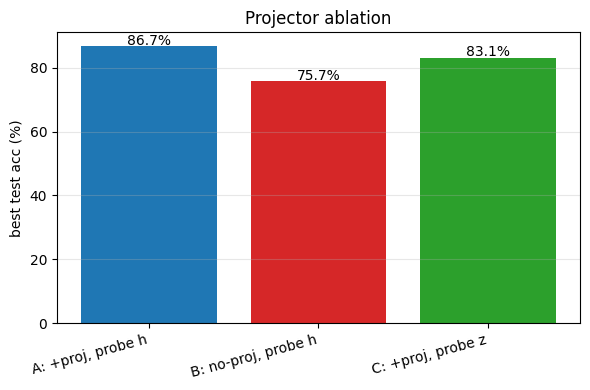

Saved figures/ablation_projector_comparison.png


In [6]:
# --- Cell 6: Results table + plot ---
def _fmt(x): return f'{x*100:.2f}%' if x is not None else '   n/a '
print('Projector ablation — CIFAR-10 linear probe')
print('=' * 60)
print(f"{'run':<28}  {'final':>8}  {'best':>8}")
print('-' * 60)
for key in ['A_proj_h', 'B_noproj_h', 'C_proj_z']:
    r = results[key]
    print(f'{r["tag"]:<28}  {_fmt(r["final_test_acc"]):>8}  {_fmt(r["best_test_acc"]):>8}')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
tags = [results[k]['tag'] for k in ['A_proj_h', 'B_noproj_h', 'C_proj_z']]
vals = [results[k]['best_test_acc']*100 for k in ['A_proj_h', 'B_noproj_h', 'C_proj_z']]
colors = ['#1f77b4', '#d62728', '#2ca02c']
ax.bar(range(3), vals, color=colors)
ax.set_xticks(range(3)); ax.set_xticklabels(tags, rotation=15, ha='right')
ax.set_ylabel('best test acc (%)'); ax.set_title('Projector ablation')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
fig.tight_layout(); fig.savefig(cfg['fig_path'], dpi=150); plt.show()
print('Saved', cfg['fig_path'])
